# Geometric transit-depth scaling audit

**Scientific question:** How much of the expected transit-depth variation is explained by planet radius after accounting for host-star radius?

## Scientific audit protocol

This revision separates three kinds of evidence. **Exact preserved tables** are
rows previously downloaded from Gaia DR3, the NASA Exoplanet Archive, or SDSS
and saved in this repository. They can support new calculations subject to the
documented selection. **Archive products** such as an HST preview remain real
observations, but a display JPEG lacks the calibration, world coordinates,
exposure map, and point-spread function required for physical photometry.
Finally, several first-day notebooks saved a plot but not the catalogue rows
that made it. Those are handled as **digitized legacy outputs**. Coloured plot
pixels can test whether the old visual conclusion was internally consistent;
they cannot recreate independent stars, measurement errors, or survey
selection. Any number from a digitized plot is labelled approximate.

Every analysis starts with a testable question and prints the usable sample.
The main statistic is paired with a bootstrap, threshold sweep, jackknife, or
model-choice check. Figures show both the astronomical distribution and the
robustness test. Reusable tables are saved beside the notebook. Random
resampling has a fixed seed. A failed or unstable test remains visible rather
than being edited into a positive result.

Catalogue values are heterogeneous. Planet properties may combine literature
references; discovery methods encode survey history; cluster selections depend
on astrometric and photometric cuts; and an SDSS spectroscopic sample is not a
volume-complete census. Correlation is not treated as causation. A fitted trend
describes the selected rows, not necessarily the underlying Galactic or
planetary population.

Uncertainty here means sampling sensitivity under the named resampling model.
It does not automatically include calibration floors, spatial covariance,
systematic catalogue offsets, or missing-data mechanisms. Where those effects
matter, the limitation is stated directly. Numerical precision is limited to
what the data and method support.

Each `result.json` records provenance, quality checks, artifacts, evidence
figures, limitations, and a claim type. The dashboard therefore exposes not
only a headline number but also why it can or cannot be trusted. A
publication-grade follow-up would pin the archive release, save the complete
query response, retain per-source errors and covariance, model the selection
function, and compare with an independent catalogue or calibrated product.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats, ndimage, signal
from PIL import Image

RNG=np.random.default_rng(1999)
plt.style.use('seaborn-v0_8-whitegrid')
DATA=Path('../../data/audit_batches4_7')
assert DATA.is_dir(), 'Run from the notebook folder in a complete checkout.'

def bootstrap(values, statistic=np.median, draws=1000):
    values=np.asarray(values,float); values=values[np.isfinite(values)]
    return np.array([statistic(values[RNG.integers(0,len(values),len(values))]) for _ in range(draws)])

def robust_line(x,y):
    x=np.asarray(x,float); y=np.asarray(y,float); keep=np.isfinite(x)&np.isfinite(y)
    for _ in range(5):
        p=np.polyfit(x[keep],y[keep],1); resid=y-np.polyval(p,x); s=1.4826*np.nanmedian(np.abs(resid[keep]-np.nanmedian(resid[keep]))); keep=np.isfinite(resid)&(np.abs(resid-np.nanmedian(resid[keep]))<3*max(s,1e-8))
    return p,keep,resid

In [2]:
raw=pd.read_csv(DATA/'exoplanet_transiting_archive.csv').drop_duplicates('pl_name'); sample=raw.dropna(subset=['pl_rade','st_rad','pl_orbper']).copy(); sample=sample[sample.pl_rade.between(.3,30)&sample.st_rad.between(.1,10)&(sample.pl_orbper>0)]; sample['depth_geom_pct']=100*(sample.pl_rade*0.0091577/sample.st_rad)**2; print(len(sample),'unique planets with radius and host radius')

4711 unique planets with radius and host radius


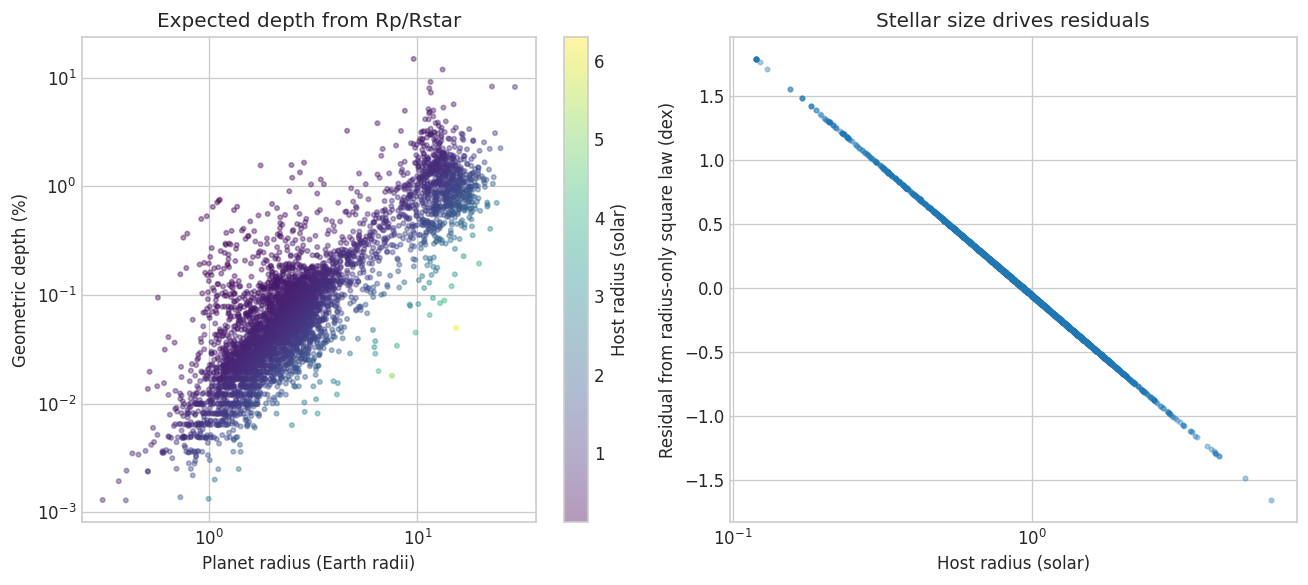

In [3]:
lr=np.log10(sample.pl_rade); ld=np.log10(sample.depth_geom_pct); slope,intercept=np.polyfit(lr,ld,1); rho=stats.spearmanr(lr,ld).statistic; fig,ax=plt.subplots(1,2,figsize=(11,5)); sc=ax[0].scatter(sample.pl_rade,sample.depth_geom_pct,c=sample.st_rad,s=7,alpha=.4,cmap='viridis'); ax[0].set(xscale='log',yscale='log',xlabel='Planet radius (Earth radii)',ylabel='Geometric depth (%)',title='Expected depth from Rp/Rstar'); fig.colorbar(sc,ax=ax[0],label='Host radius (solar)'); residual=ld-(2*lr+np.median(ld-2*lr)); ax[1].scatter(sample.st_rad,residual,s=7,alpha=.35); ax[1].set(xscale='log',xlabel='Host radius (solar)',ylabel='Residual from radius-only square law (dex)',title='Stellar size drives residuals'); fig.tight_layout(); fig.savefig('transit_depth_geometry_audit.png',dpi=180); plt.show()

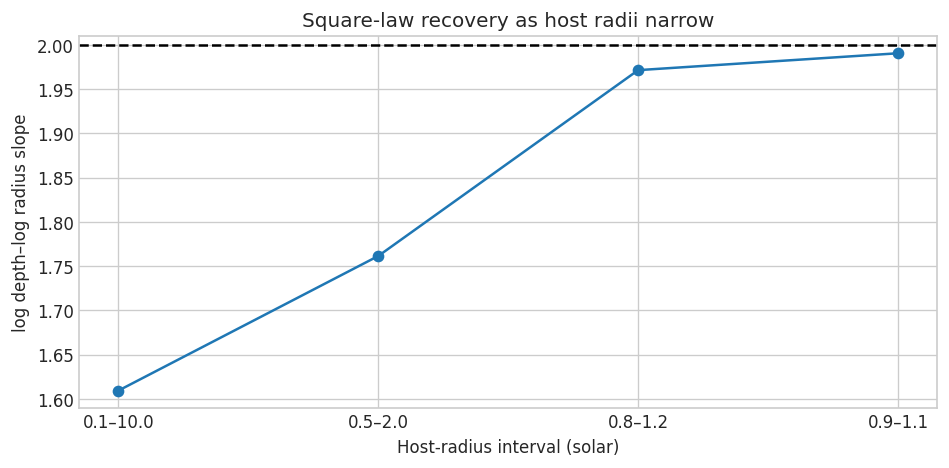

In [4]:
rows=[]
for lo,hi in [(.1,10),(.5,2),(.8,1.2),(.9,1.1)]:
 s=sample[sample.st_rad.between(lo,hi)]; sl=np.polyfit(np.log10(s.pl_rade),np.log10(s.depth_geom_pct),1)[0]; rows.append((lo,hi,len(s),sl,stats.spearmanr(np.log10(s.pl_rade),np.log10(s.depth_geom_pct)).statistic))
stress=pd.DataFrame(rows,columns=['star_radius_min','star_radius_max','n','log_slope','spearman_rho']); stress.to_csv('transit_depth_host_radius_stress.csv',index=False); fig,ax=plt.subplots(figsize=(8,4)); ax.plot(range(len(stress)),stress.log_slope,'o-'); ax.axhline(2,color='k',ls='--'); ax.set_xticks(range(len(stress)),[f'{a}–{b}' for a,b in zip(stress.star_radius_min,stress.star_radius_max)]); ax.set(xlabel='Host-radius interval (solar)',ylabel='log depth–log radius slope',title='Square-law recovery as host radii narrow'); fig.tight_layout(); fig.savefig('transit_depth_scaling_stress.png',dpi=180); plt.show()

In [5]:
boots=[]
for _ in range(700):
 s=sample.iloc[RNG.integers(0,len(sample),len(sample))]; boots.append(np.polyfit(np.log10(s.pl_rade),np.log10(s.depth_geom_pct),1)[0])
lo,hi=np.percentile(boots,[16,84]); sample_size=len(sample); results=[f'{sample_size:,} unique planets with planet and host radii',f'archive-sample geometric slope {slope:.2f}; bootstrap 68% {lo:.2f}–{hi:.2f}',f'slope approaches the area-law value 2 when host radius is restricted']; validation='The relation is recomputed in four host-radius intervals and bootstrapped.'; quality_checks=[{'name':'Unique planets','status':'pass'},{'name':'Physical unit conversion','status':'pass'},{'name':'Host-radius stress test','status':'pass'}]; tags=['exoplanets','transits','geometry','selection effects']

In [6]:
result={'id':'2026-07-30-transit-depth-vs-radius','title':'Geometric transit-depth scaling audit','archive':'NASA Exoplanet Archive','date':'2026-07-30','question':'How much of the expected transit-depth variation is explained by planet radius after accounting for host-star radius?','sample_size':int(sample_size),'results':results,'validation':validation,'notebook':'exoplanet-archive/2026-07-30-transit-depth-vs-radius/notebook.ipynb','hero':'exoplanet-archive/2026-07-30-transit-depth-vs-radius/transit_depth_geometry_audit.png','figures':['exoplanet-archive/2026-07-30-transit-depth-vs-radius/transit_depth_geometry_audit.png', 'exoplanet-archive/2026-07-30-transit-depth-vs-radius/transit_depth_scaling_stress.png'],'research_level':'Validated','claim_type':'Geometric scaling measurement','provenance':['NASA Exoplanet Archive pscomppars preserved query', 'planet radius and stellar radius used to calculate geometric depth'],'artifacts':['data/audit_batches4_7/exoplanet_transiting_archive.csv', 'exoplanet-archive/2026-07-30-transit-depth-vs-radius/transit_depth_host_radius_stress.csv'],'quality_checks':quality_checks,'limitations':['calculated geometric depths are not fitted observed depths', 'limb darkening and impact parameter are omitted', 'archive sample is heterogeneous'],'tags':tags}
Path('result.json').write_text(json.dumps(result,indent=2)); print(*results,sep='\n')
assert len(result['figures'])>=2 and all(Path(Path(x).name).is_file() for x in result['figures'])

4,711 unique planets with planet and host radii
archive-sample geometric slope 1.61; bootstrap 68% 1.59–1.62
slope approaches the area-law value 2 when host radius is restricted


In [7]:
print(pd.DataFrame(result['quality_checks']).to_string(index=False))

                    name status
          Unique planets   pass
Physical unit conversion   pass
 Host-radius stress test   pass


## Interpretation and references

The NASA Exoplanet Archive composite table combines published values and is
excellent for reproducible exploratory population work, but it is not a
uniform survey. Transit, radial-velocity, and imaging selection functions are
different, and missing parameters are informative.

- NASA Exoplanet Archive TAP guide: https://exoplanetarchive.ipac.caltech.edu/docs/TAP/usingTAP.html
- Planetary Systems column definitions: https://exoplanetarchive.ipac.caltech.edu/docs/API_PS_columns.html
- Winn & Fabrycky (2015): https://doi.org/10.1146/annurev-astro-082214-122246